# Evaluierung & Benchmark: Faktenkonsistenz und Halluzinationserkennung
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook führt eine empirische Vergleichsstudie von **5 Bewertungsansätzen** zur Erkennung von **Faktenverzerrungen, Zahlenfehlern und semantischen Halluzinationen** durch:
1. **SBERT Baseline (Bi-Encoder):** `sentence-transformers/paraphrase-multilingual-mpnet-base-v2`
2. **NLI Cross-Encoder:** `cross-encoder/nli-distilroberta-base` (Entailment / Contradiction)
3. **Klassischer NER-Overlap:** SpaCy `de_core_news_sm` (Jaccard-Ähnlichkeit & Recall)
4. **Numerischer Slot-Check:** Reguläre Ausdrücke zur Erkennung nicht geerdeter Zahlen
5. **Hybride Multiplikative Metrik:** $R_{\text{fact}} = R_{\text{SBERT}} \cdot R_{\text{NLI}} \cdot R_{\text{Num}}$

### Untersuchte 4 Testklassen ($N = 177$ Textpaare):
- **Klasse 1: Gold Positives ($N=77$):** Menschliche Referenzen (Lebenshilfe & Master Parallelkorpus)
- **Klasse 2: Reale Modell-Halluzinationen ($N=40$):** Echte SFT/DPO-Ausgaben aus `dpo_pairs_w05_w05.jsonl` (Costa Concordia, NZZ 2047, Ferrari-Fahrer, Sachsen-Anhalt in Zürich)
- **Klasse 3: Random Shuffle Negatives ($N=30$):** Zufällig durchgetauschte Paare (Themenwechsel)
- **Klasse 4: Kontrollierte Minimal-Perturbationen ($N=30$):** Gezielte Mutationen von Zahlen, Negationen und Rollen auf Gold-Sätzen

In [1]:
# ==============================================================================
# 1. SYSTEM-SETUP & IMPORTE
# ==============================================================================
import os
import sys
import glob
import json
import re
import random
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score

# Sicheres Setzen des Projekt-Wurzelverzeichnisses (sucht nach 'data' und 'scripts')
start_dir = os.getcwd()
while not (os.path.exists("data") and os.path.exists("scripts")):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():  # Root des Dateisystems erreicht
        os.chdir(start_dir)
    os.chdir("..")

if not (os.path.exists("data") and os.path.exists("scripts")):
        if os.path.exists(candidate) and os.path.exists(os.path.join(candidate, "data")):
            os.chdir(candidate)

print("Arbeitsverzeichnis:", os.getcwd())
print(f"Nutze Device: {DEVICE}")

# Publication-quality plot style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150
})


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis
Nutze Device: mps


## 1. Faktenkonsistenz-Evaluationsdaten laden


In [2]:
# ==============================================================================
# 2. EVALUATIONSDATEN LADEN
# ==============================================================================
CSV_PATH = "results/evaluation/factual_consistency_metric_results.csv"
if not os.path.exists(CSV_PATH):
    CSV_PATH = "../../../results/evaluation/factual_consistency_metric_results.csv"

df_res = pd.read_csv(CSV_PATH)
print(f"Ergebnisse geladen: {len(df_res)} Textpaare aus {CSV_PATH}")
display(df_res.head(3))


## 2. Quantitative Vergleichstabelle nach Testklasse


In [3]:
# ==============================================================================
# 3. KERNMETRIKEN-TABELLE NACH TESTKLASSE
# ==============================================================================
metrics_cols = {
    "sbert_score": "SBERT Similarity (R_sem)",
    "nli_factuality": "NLI Factuality Score",
    "nli_p_contra": "NLI P(Contradiction)",
    "ner_jaccard": "NER Jaccard Overlap",
    "number_consistency": "Number Consistency Check",
    "composite_factuality": "Composite Multiplicative Score"
}

df_summary = df_res.groupby("category")[list(metrics_cols.keys())].mean().rename(columns=metrics_cols)
df_std = df_res.groupby("category")[list(metrics_cols.keys())].std().rename(columns=metrics_cols)

formatted_rows = []
for cat in df_summary.index:
    row = {"Testklasse": cat}
    for col in df_summary.columns:
        row[col] = f"{df_summary.loc[cat, col]:.4f} ± {df_std.loc[cat, col]:.4f}"
    formatted_rows.append(row)

df_table = pd.DataFrame(formatted_rows)
try:
    display(df_table)
except Exception:
    print(df_table.to_string(index=False))


,Testklasse,SBERT Similarity (R_sem),NLI Factuality Score,NLI P(Contradiction),NER Jaccard Overlap,Number Consistency Check,Composite Multiplicative Score
0,1_Gold_Positives,0.8877 ± 0.0679,0.4547 ± 0.0697,0.2530 ± 0.1459,0.1345 ± 0.1064,0.6343 ± 0.3616,0.2606 ± 0.1558
1,2_Real_Model_Hallucinations,0.8687 ± 0.0627,0.4452 ± 0.1292,0.3101 ± 0.1527,0.2032 ± 0.1405,0.7915 ± 0.3089,0.3066 ± 0.1417
2,3_Random_Shuffle_Negatives,0.6523 ± 0.0750,0.4461 ± 0.1106,0.3123 ± 0.1831,0.0039 ± 0.0101,0.3003 ± 0.3783,0.0862 ± 0.1123
3,4_Targeted_Minimal_Perturbations,0.7934 ± 0.0971,0.4027 ± 0.1911,0.4091 ± 0.3084,0.6778 ± 0.4484,0.8167 ± 0.3824,0.2878 ± 0.1827


## 3. Publikationsreife Verteilungsanalyse (4-Panel Boxplots)


<>:27: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
<>:27: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_66545/3994822111.py:27: SyntaxWarning: "\c" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\c"? A raw string is also an option.
  axes[1, 1].set_title("(D) Hybrider Composite Score ($R_{sem} \cdot R_{NLI} \cdot R_{Num}$)", fontsize=13, fontweight="bold")
/var/folders/b4/clxxd_yn5655dz4hq58pqznh0000gn/T/ipykernel_66545/3994822111.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(["Gold\nPositives", "Real\nHallucinations", "Random\nShuffle", "Minimal\nPerturbations"], fonts

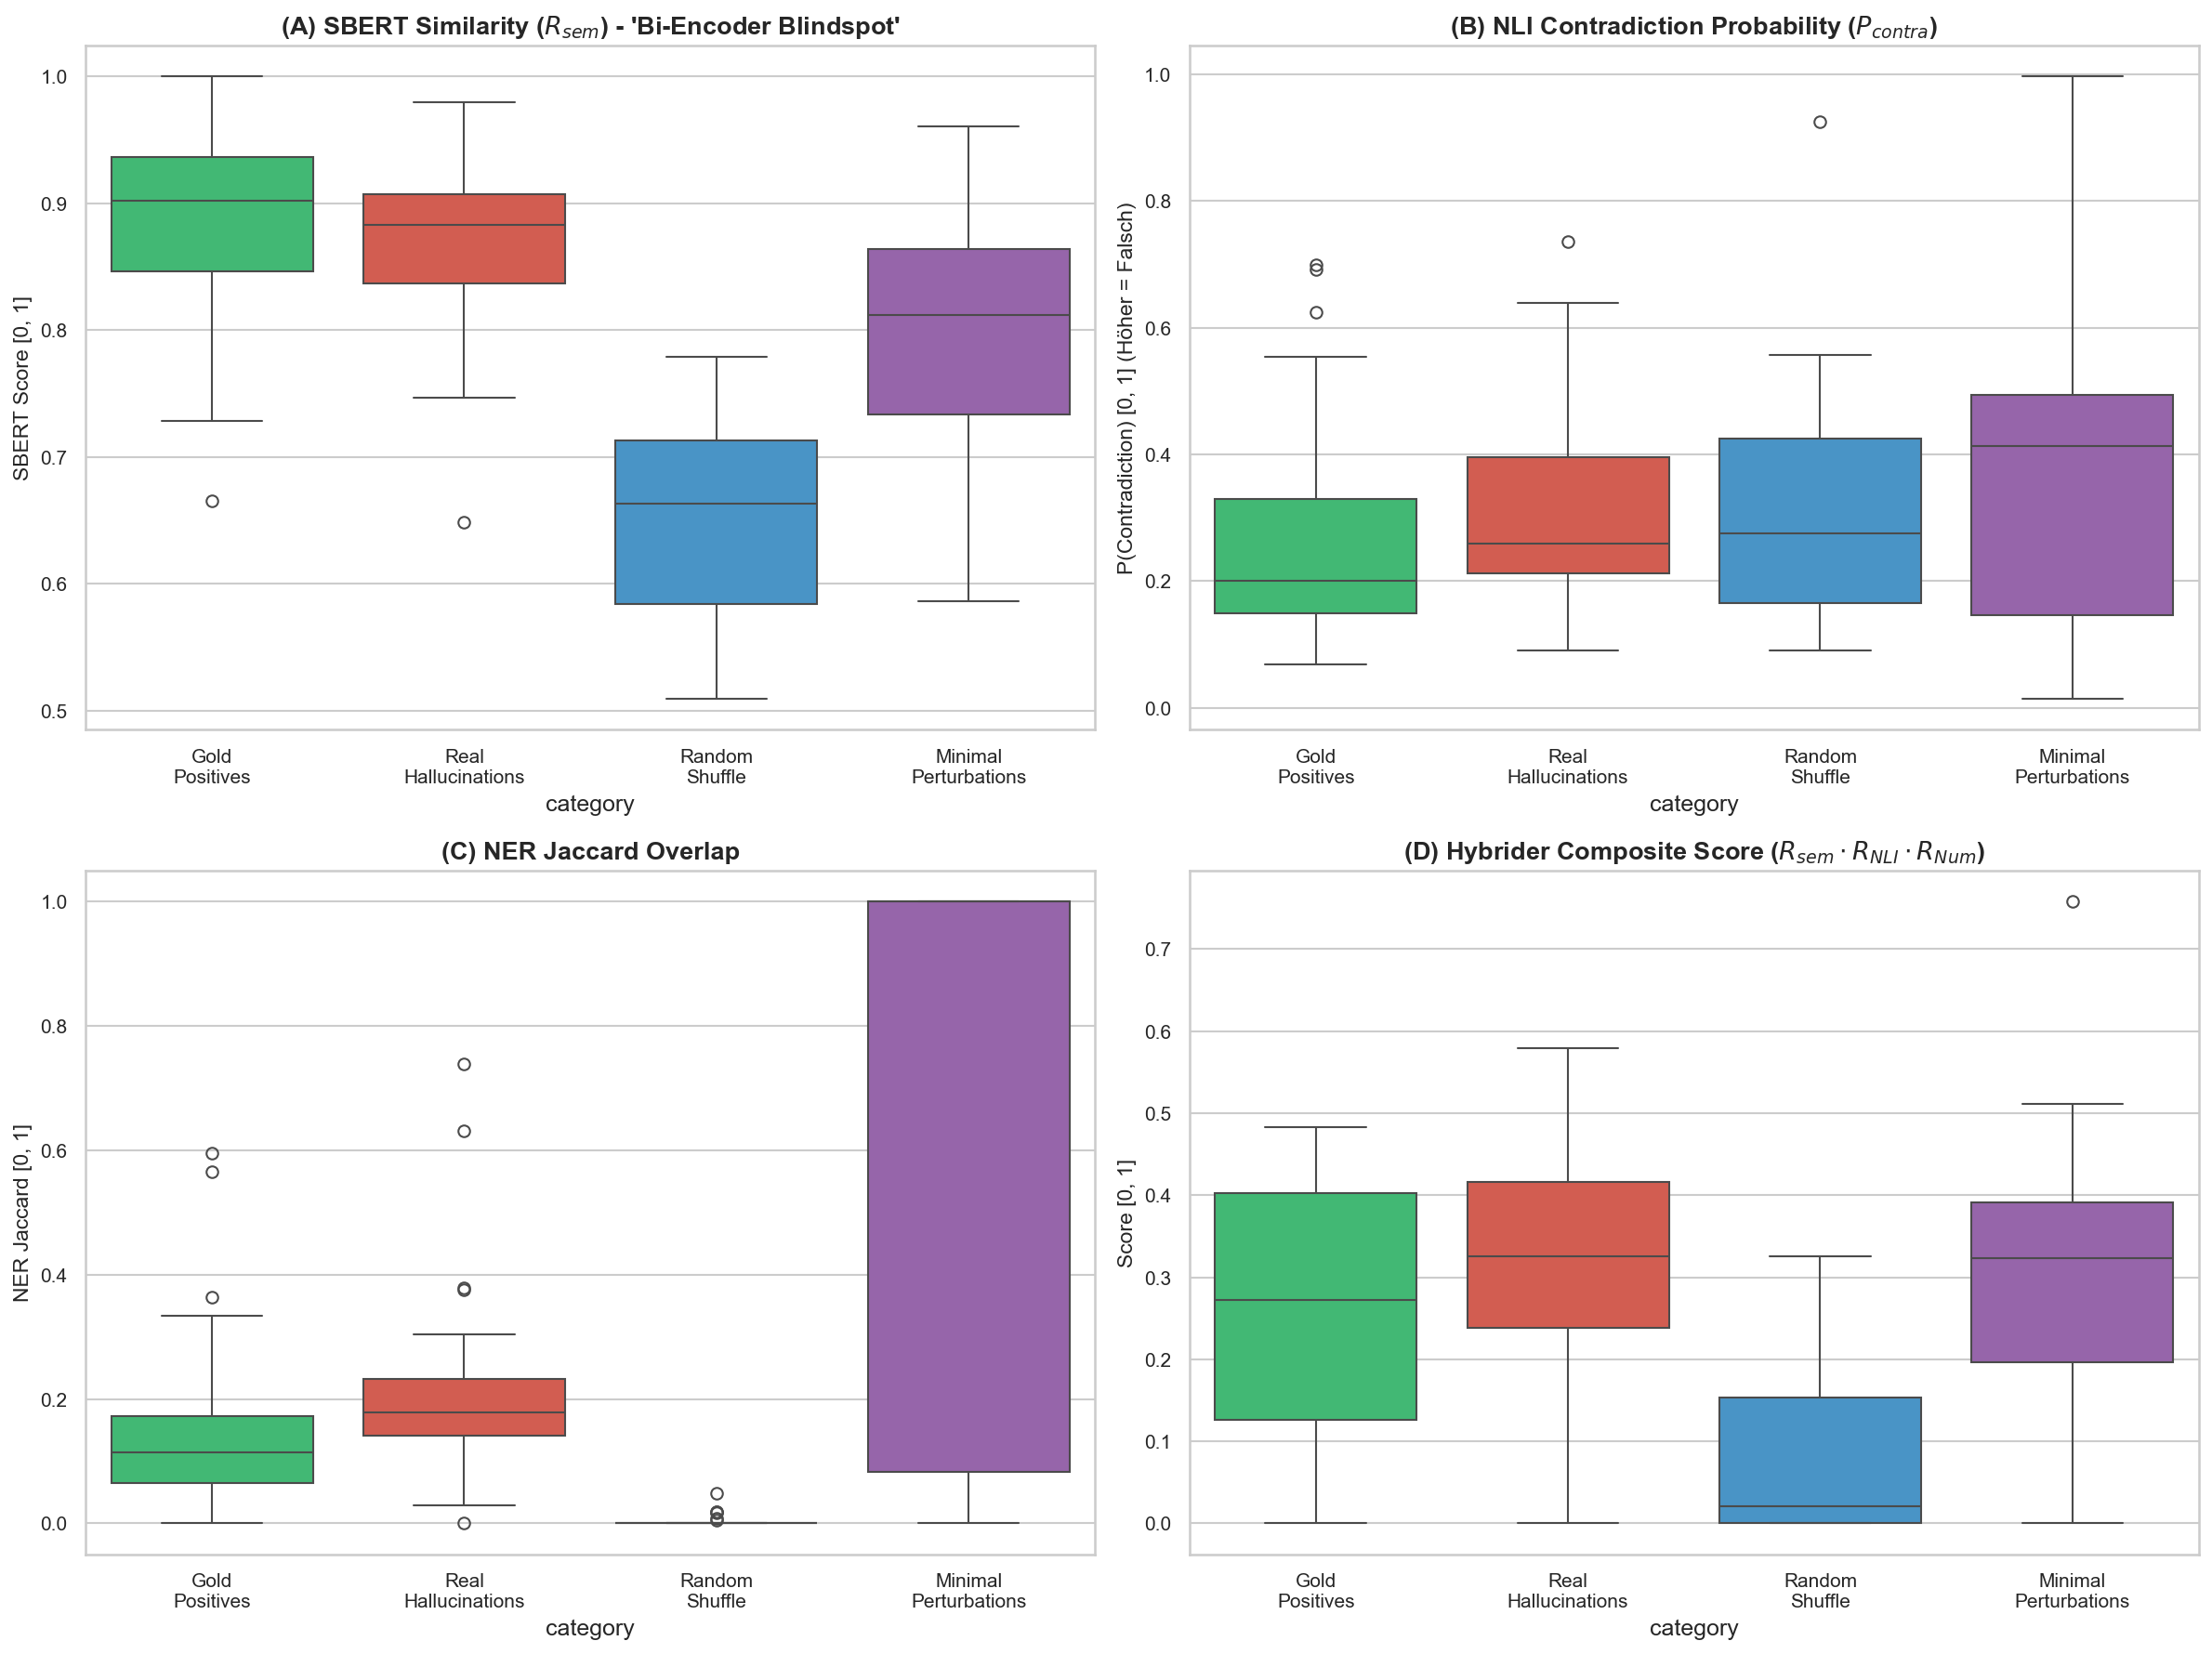

Plot gespeichert unter: research/img/analysis/factuality_metrics_4panel_comparison.png


In [4]:
# ==============================================================================
# 4. VISUALISIERUNG: 4-PANEL VERGLEICHSPLOTS
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = ["#2ecc71", "#e74c3c", "#3498db", "#9b59b6"]

# 1. SBERT Similarity
sns.boxplot(ax=axes[0, 0], data=df_res, x="category", y="sbert_score", hue="category", palette=palette, legend=False)
axes[0, 0].set_title("(A) SBERT Similarity ($R_{sem}$) - 'Bi-Encoder Blindspot'", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("SBERT Score [0, 1]", fontsize=11)
axes[0, 0].set_xticklabels(["Gold\nPositives", "Real\nHallucinations", "Random\nShuffle", "Minimal\nPerturbations"], fontsize=10)

# 2. NLI P(Contradiction)
sns.boxplot(ax=axes[0, 1], data=df_res, x="category", y="nli_p_contra", hue="category", palette=palette, legend=False)
axes[0, 1].set_title("(B) NLI Contradiction Probability ($P_{contra}$)", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("P(Contradiction) [0, 1] (Höher = Falsch)", fontsize=11)
axes[0, 1].set_xticklabels(["Gold\nPositives", "Real\nHallucinations", "Random\nShuffle", "Minimal\nPerturbations"], fontsize=10)

# 3. NER Jaccard Overlap
sns.boxplot(ax=axes[1, 0], data=df_res, x="category", y="ner_jaccard", hue="category", palette=palette, legend=False)
axes[1, 0].set_title("(C) NER Jaccard Overlap", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("NER Jaccard [0, 1]", fontsize=11)
axes[1, 0].set_xticklabels(["Gold\nPositives", "Real\nHallucinations", "Random\nShuffle", "Minimal\nPerturbations"], fontsize=10)

# 4. Composite Multiplicative Score
sns.boxplot(ax=axes[1, 1], data=df_res, x="category", y="composite_factuality", hue="category", palette=palette, legend=False)
axes[1, 1].set_title("(D) Hybrider Composite Score ($R_{sem} \cdot R_{NLI} \cdot R_{Num}$)", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Score [0, 1]", fontsize=11)
axes[1, 1].set_xticklabels(["Gold\nPositives", "Real\nHallucinations", "Random\nShuffle", "Minimal\nPerturbations"], fontsize=10)

plt.tight_layout()
plot_out = "research/img/analysis/factuality_metrics_4panel_comparison.png"
os.makedirs(os.path.dirname(plot_out), exist_ok=True)
plt.savefig(plot_out, dpi=300, bbox_inches="tight")
plt.show()
print(f"Plot gespeichert unter: {plot_out}")


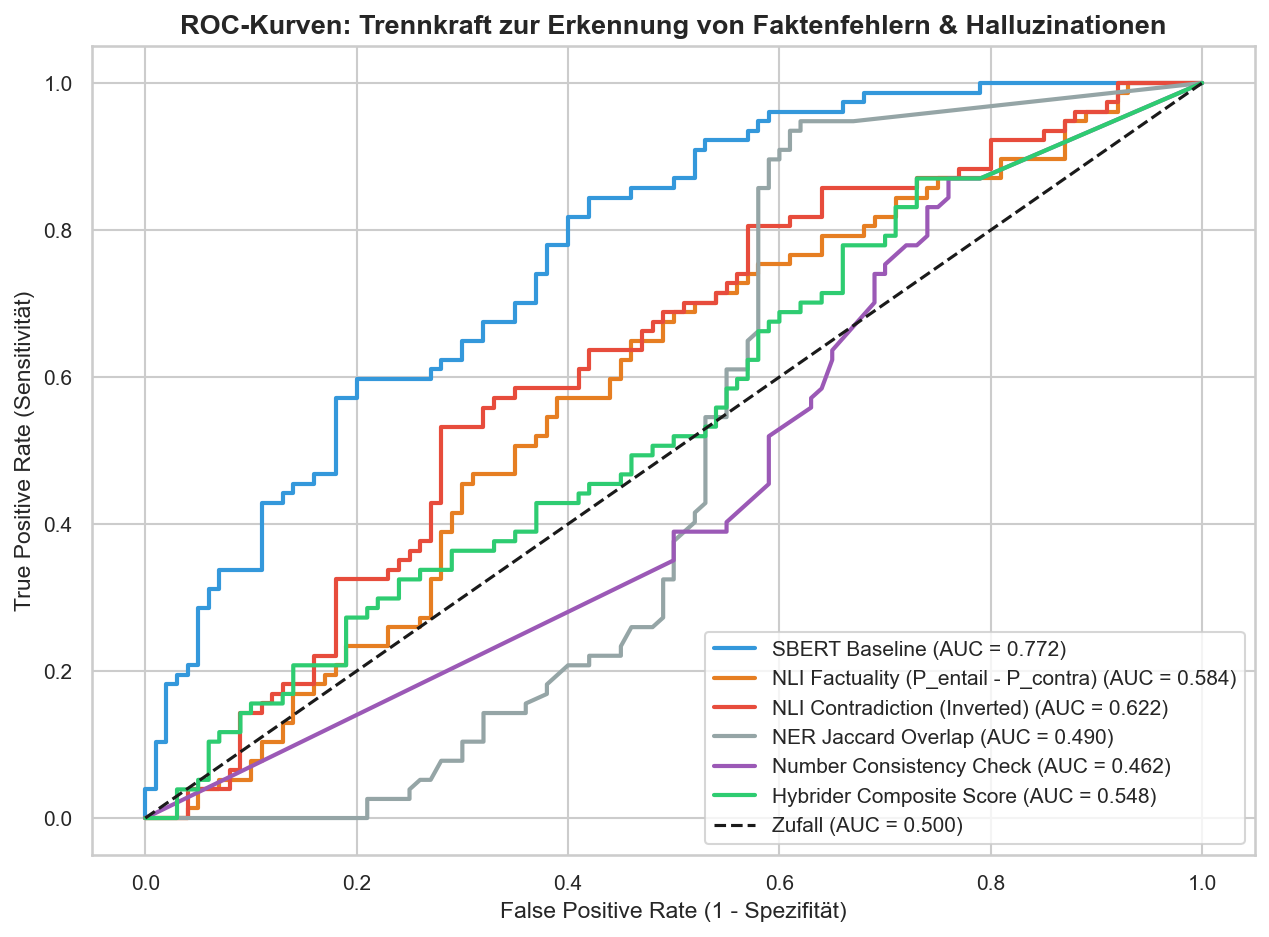

ROC Plot gespeichert unter: research/img/analysis/factuality_metrics_roc_curves.png


In [5]:
# ==============================================================================
# 5. ROC-KURVEN & TRENNKRAFT-ANALYSE
# ==============================================================================
plt.figure(figsize=(10, 7))
y_true = df_res["is_factually_correct"].values

eval_configs = [
    ("SBERT Baseline", df_res["sbert_score"].values, "#3498db"),
    ("NLI Factuality (P_entail - P_contra)", df_res["nli_factuality"].values, "#e67e22"),
    ("NLI Contradiction (Inverted)", 1.0 - df_res["nli_p_contra"].values, "#e74c3c"),
    ("NER Jaccard Overlap", df_res["ner_jaccard"].values, "#95a5a6"),
    ("Number Consistency Check", df_res["number_consistency"].values, "#9b59b6"),
    ("Hybrider Composite Score", df_res["composite_factuality"].values, "#2ecc71"),
]

for name, scores, color in eval_configs:
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], "k--", lw=1.5, label="Zufall (AUC = 0.500)")
plt.xlabel("False Positive Rate (1 - Spezifität)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivität)", fontsize=11)
plt.title("ROC-Kurven: Trennkraft zur Erkennung von Faktenfehlern & Halluzinationen", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=10)

roc_out = "research/img/analysis/factuality_metrics_roc_curves.png"
plt.savefig(roc_out, dpi=300, bbox_inches="tight")
plt.show()
print(f"ROC Plot gespeichert unter: {roc_out}")


## 4. Qualitative Fallstudien (Modell-Halluzinationen & Perturbationen)


In [6]:
# ==============================================================================
# 6. QUALITATIVE FALLSTUDIEN: DIE BEKANNTEN SFT-HALLUZINATIONEN
# ==============================================================================
case_studies = df_res[df_res["category"].isin(["2_Real_Model_Hallucinations", "4_Targeted_Minimal_Perturbations"])].head(6)

print("="*95)
print("DETAIL-INSPEKTION: WIE REAGIEREN DIE METRIKEN AUF KONKRETE FEHLER?")
print("="*95)

for idx, row in case_studies.iterrows():
    print(f"\n[FALL {idx+1}] Subtyp: {row['subtype']} | Klasse: {row['category']}")
    print(f"AS-QUELLE: {row['as_text'][:120]}...")
    print(f"LS-ZIEL:   {row['ls_text'][:120]}...")
    print(f"-> SBERT Score:        {row['sbert_score']:.3f} (Täuschend hoch? {'⚠️ JA' if row['sbert_score'] > 0.80 else '✅ NEIN'})")
    print(f"-> NLI P(Contra):      {row['nli_p_contra']:.3f} (Widerspruch erkannt? {'✅ JA' if row['nli_p_contra'] > 0.35 else '⚠️ NEIN'})")
    print(f"-> NER Jaccard:        {row['ner_jaccard']:.3f}")
    print(f"-> Number Consistency: {row['number_consistency']:.3f}")
    print(f"-> Composite Score:    {row['composite_factuality']:.3f}")
    print("-"*95)


DETAIL-INSPEKTION: WIE REAGIEREN DIE METRIKEN AUF KONKRETE FEHLER?

[FALL 78] Subtyp: mBART_SFT_10kgnad_panorama | Klasse: 2_Real_Model_Hallucinations
AS-QUELLE: Früherer Kapitän in erster Instanz zu 16 Jahren verurteilt – Staatsanwaltschaft will jetzt 27 Jahre Haft. Florenz – Mehr...
LS-ZIEL:   Was passiert mit der Costa Concordia vor der Mittelmeerinsel Giglio? Florenz – Florenz ist eine Stadt im Bundes-Land Ita...
-> SBERT Score:        0.843 (Täuschend hoch? ⚠️ JA)
-> NLI P(Contra):      0.091 (Widerspruch erkannt? ⚠️ NEIN)
-> NER Jaccard:        0.304
-> Number Consistency: 0.500
-> Composite Score:    0.380
-----------------------------------------------------------------------------------------------

[FALL 79] Subtyp: mBART_SFT_10kgnad_sport | Klasse: 2_Real_Model_Hallucinations
AS-QUELLE: Südstädter müssen sich dem Vizemeister zu Hause 1:3 geschlagen geben, spielen dennoch kommende Saison international. Mar...
LS-ZIEL:   Was passiert in der Fußball-Bundesliga? In der Bundes-Li